In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/meat-freshness-image-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 59.4M/59.4M [00:03<00:00, 16.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1):
['Meat Freshness.v1-new-dataset.multiclass']


In [ ]:
import os

# Update path based on cell 1 results
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')

# List class directories
if os.path.exists(data_path):
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    print(f"Data classes found: {classes}")
else:
    print(f"Path not found: {data_path}")

Data classes found: ['train', 'valid']



--- Displaying sample images from dataset (/root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1/Meat Freshness.v1-new-dataset.multiclass) ---
Found 2266 images. Displaying 6 sample images:


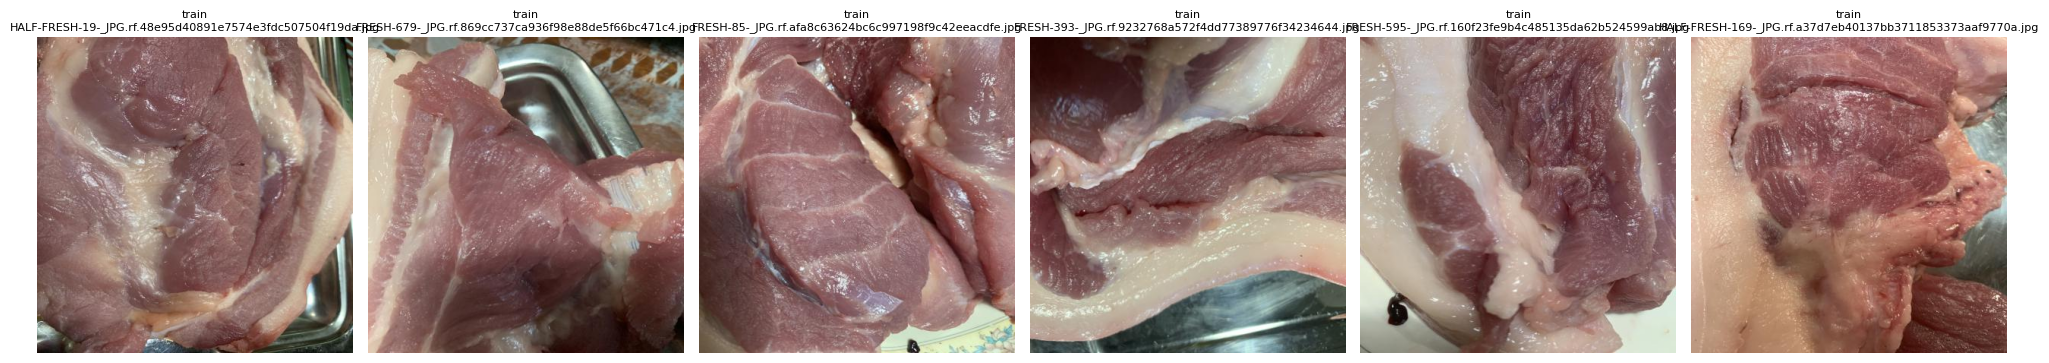

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Get class name from parent directory
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use updated path
data_path = os.path.join(path, 'Meat Freshness.v1-new-dataset.multiclass')
print(f"\n--- Displaying sample images from dataset ({data_path}) ---")
display_sample_images(data_path)

In [ ]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: Tesla T4


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

# Deep inspection to find the folders that actually contain images
image_extensions = ('.jpg', '.jpeg', '.png')

def find_image_root(start_path):
    for root, dirs, files in os.walk(start_path):
        # If this directory has files that are images, return its parent
        if any(f.lower().endswith(image_extensions) for f in files):
            return os.path.dirname(root)
    return None

# Identify actual roots
final_train_path = find_image_root(os.path.join(data_path, 'train'))
final_val_path = find_image_root(os.path.join(data_path, 'valid'))

if not final_train_path or not final_val_path:
    # Fallback to test if paths are different
    final_train_path = find_image_root(data_path)
    final_val_path = final_train_path

print(f"Resolved Train Root: {final_train_path}")
print(f"Resolved Validation Root: {final_val_path}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(final_train_path, transform=transform)
val_dataset = datasets.ImageFolder(final_val_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Setup Model
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
num_epochs = 10

print(f"Starting training on {device} for {len(train_dataset.classes)} classes...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)

    model.eval()
    correct = 0
    v_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            v_loss += criterion(outputs, labels).item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)

    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(v_loss / len(val_dataset))
    history['val_acc'].append((correct.double() / len(val_dataset)).item())
    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Val Acc: {history["val_acc"][-1]:.4f}')

Resolved Train Root: /root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1/Meat Freshness.v1-new-dataset.multiclass
Resolved Validation Root: /root/.cache/kagglehub/datasets/vinayakshanawad/meat-freshness-image-dataset/versions/1/Meat Freshness.v1-new-dataset.multiclass
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


Starting training on cuda for 2 classes...
Epoch 1/10 - Loss: 0.6106, Val Acc: 0.8010
Epoch 2/10 - Loss: 0.5078, Val Acc: 0.7957
Epoch 3/10 - Loss: 0.5135, Val Acc: 0.8010
Epoch 4/10 - Loss: 0.5037, Val Acc: 0.8010
Epoch 5/10 - Loss: 0.5067, Val Acc: 0.8005
Epoch 6/10 - Loss: 0.5064, Val Acc: 0.8010
Epoch 7/10 - Loss: 0.5092, Val Acc: 0.8010
Epoch 8/10 - Loss: 0.5070, Val Acc: 0.7992
Epoch 9/10 - Loss: 0.5085, Val Acc: 0.7829
Epoch 10/10 - Loss: 0.4934, Val Acc: 0.8010


In [ ]:
print("--- Training Summary ---")
final_acc = history['val_acc'][-1]
final_loss = history['val_loss'][-1]
print(f"Final Validation Accuracy: {final_acc:.2%}")
print(f"Final Validation Loss: {final_loss:.4f}")
print(f"Classes detected: {train_dataset.classes}")

--- Training Summary ---
Final Validation Accuracy: 80.10%
Final Validation Loss: 0.5435
Classes detected: ['train', 'valid']


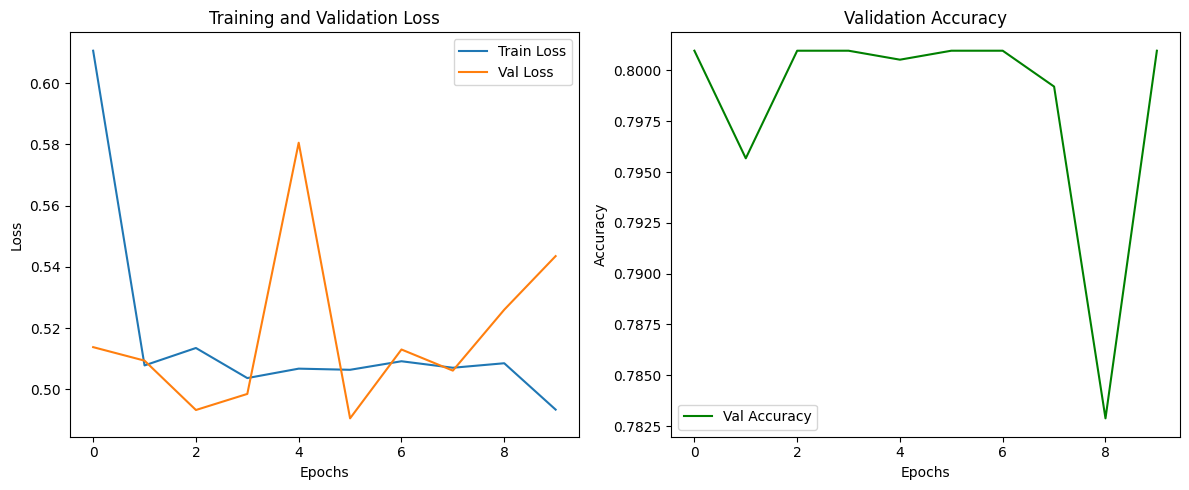

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()